# GalaxIA — Día 2: KNN y redes densas

Cuatro modelos nuevos, todos sobre el **mismo split congelado** del día 1:

| Modelo | Entradas | Qué prueba |
|---|---|---|
| KNN | PCA de píxeles | Calidad de la representación PCA |
| MLP-PCA | PCA de píxeles | Frontera no lineal sobre los mismos datos |
| MLP-Params | 24 parámetros morfológicos | **Experimento tipo Banerji 2010** |
| MLP-Fusión | PCA + parámetros | ¿Suman o se solapan? |

La CNN se lanza aparte desde terminal (última sección) para no bloquear el notebook.

**Referencia del día 1** — SVM (RGB + recorte): acc 0.8616, F1-macro 0.8357, AUC 0.9505.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import sys, time, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from galaxia import data, labels, features, models, evaluate
data.fijar_semillas(42)

2026-08-26 20:53:03.069132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787795583.080017   77676 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787795583.083263   77676 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787795583.092814   77676 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787795583.092829   77676 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787795583.092831   77676 computation_placer.cc:177] computation placer alr

In [2]:
# Mismo etiquetado y mismo umbral que el día 1
df = labels.construir_etiquetas(data.cargar_csv())

p = data.DIR_PROC / "umbral.json"
UMBRAL = json.loads(p.read_text())["umbral"] if p.exists() else 0.6
print("Umbral:", UMBRAL)

df_clean = labels.filtrar_por_confianza(df, umbral=UMBRAL)
d = data.preparar_conjunto(df_clean, size=128)
clases, le = d["clases"], d["label_encoder"]

ytr, yva, yte = d["train"]["y"], d["val"]["y"], d["test"]["y"]
print(f"train {len(ytr)} | val {len(yva)} | test {len(yte)}")
print(dict(zip(clases, np.bincount(ytr))))

Umbral: 0.8
train 11940 | val 2108 | test 3512
{'Disk': np.int64(1770), 'Smooth': np.int64(5530), 'Spiral': np.int64(4640)}


## 1. Características

Dos representaciones. Los píxeles a 64x64 RGB (12 288 dims) van al PCA;
los 24 parámetros morfológicos van directos.

In [3]:
t0 = time.time()
Xtr_px = features.a_vector(np.array(d["train"]["X"]), size=64)
Xva_px = features.a_vector(np.array(d["val"]["X"]),   size=64)
Xte_px = features.a_vector(np.array(d["test"]["X"]),  size=64)
print(f"píxeles: {Xtr_px.shape}  ({time.time()-t0:.0f}s)")

píxeles: (11940, 12288)  (1s)


In [4]:
# Parámetros morfológicos (generados en el día 1). Si no existen, se calculan.
ruta_par = data.DIR_PROC / "parametros.npz"
if not ruta_par.exists():
    imgs, ids_cache = data.cargar_cache(128)
    P = features.lote_parametros(np.array(imgs))
    np.savez_compressed(ruta_par, P=P, ids=ids_cache,
                        nombres=np.array(features.NOMBRES_PARAMETROS))

z = np.load(ruta_par, allow_pickle=True)
mapa = {int(g): i for i, g in enumerate(z["ids"])}
sel = lambda ids: z["P"][[mapa[int(g)] for g in ids]]

Xtr_pa = sel(d["train"]["ids"])
Xva_pa = sel(d["val"]["ids"])
Xte_pa = sel(d["test"]["ids"])
print("parámetros:", Xtr_pa.shape)

parámetros: (11940, 24)


## 2. KNN con GridSearchCV

El `Pipeline` lleva `memory=`, así que el PCA se calcula una vez por pliegue y
no una vez por combinación de hiperparámetros: 30 combinaciones x 5 pliegues
pasan de ~30 min a ~2-3 min.

KNN **sin** reducción de dimensionalidad colapsa por la maldición de la
dimensionalidad: en 12 288 dims todas las distancias se parecen. El PCA no es
opcional aquí, es lo que hace viable el método.

In [5]:
import time
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
# ---------------------------------------------------------------------
# 1. PCA una sola vez, ajustado SOLO con train.
#    'randomized' es aproximado pero rapidísimo y con 400 componentes
#    la aproximación es excelente para este rango de varianza.
# ---------------------------------------------------------------------
N_MAX = 400
prep = Pipeline([
    ("sc", StandardScaler()),
    ("pca", PCA(n_components=N_MAX, svd_solver="randomized", random_state=42)),
])

t0 = time.time()
Ztr_full = prep.fit_transform(Xtr_px)
print(f"PCA ajustado en {time.time()-t0:.0f}s")

# Elegir k para el 95 % de varianza, ya con los valores singulares en mano
var = np.cumsum(prep["pca"].explained_variance_ratio_)
if var[-1] < 0.95:
    print(f"AVISO: {N_MAX} componentes solo cubren el {var[-1]*100:.1f} %. "
          f"Sube N_MAX a 800 y vuelve a correr esta celda.")
    K = N_MAX
else:
    K = int(np.searchsorted(var, 0.95) + 1)
print(f"{K} componentes explican el {var[K-1]*100:.1f} % de la varianza "
      f"(de {Xtr_px.shape[1]} dimensiones originales)")

Ztr = Ztr_full[:, :K]
Zva = prep.transform(Xva_px)[:, :K]
Zte_ = prep.transform(Xte_px)[:, :K]
del Ztr_full

joblib.dump({"prep": prep, "K": K}, data.RAIZ / "models" / "pca_px.pkl")
print("RAM del conjunto reducido:", round(Ztr.nbytes / 1e6, 1), "MB")

PCA ajustado en 20s
AVISO: 400 componentes solo cubren el 91.5 %. Sube N_MAX a 800 y vuelve a correr esta celda.
400 componentes explican el 91.5 % de la varianza (de 12288 dimensiones originales)
RAM del conjunto reducido: 19.1 MB


In [7]:
# ---------------------------------------------------------------------
# 2. GridSearch solo sobre el KNN. Ahora cada ajuste es trivial.
#
#    NOTA METODOLÓGICA (documentar en la ponencia): el PCA se ajusta con
#    todo el train antes de la validación cruzada, así que hay un contacto
#    leve entre pliegues al SELECCIONAR hiperparámetros. El conjunto de
#    test permanece intacto, de modo que la métrica final que se reporta
#    sigue siendo limpia.
# ---------------------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

grid = {
    "n_neighbors": [3, 7, 15, 25, 41],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "cosine"],
}
gs = GridSearchCV(KNeighborsClassifier(), grid, cv=5, scoring="f1_macro",
                  n_jobs=4, verbose=1)   # 4, no -1: cada worker copia los datos

t0 = time.time(); gs.fit(Ztr, ytr); t_fit = time.time() - t0
print(f"\n{t_fit/60:.1f} min | mejor F1-macro (CV): {gs.best_score_:.4f}")
print(gs.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits

0.7 min | mejor F1-macro (CV): 0.7854
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}


In [8]:
# ---------------------------------------------------------------------
# 3. Evaluación sobre el test congelado
# ---------------------------------------------------------------------
t0 = time.time(); proba = gs.predict_proba(Zte_); t_inf = time.time() - t0
r_knn = evaluate.evaluar("KNN", yte, proba.argmax(1), proba, clases, t_fit, t_inf)
print(f"KNN: acc={r_knn['accuracy']:.4f}  F1-macro={r_knn['macro_f1']:.4f}"
      f"  AUC={r_knn['roc_auc_macro']:.4f}")

np.savez_compressed(evaluate.DIR_REP / "pred_knn.npz",
                    y_true=yte, y_pred=proba.argmax(1), proba=proba,
                    ids=d["test"]["ids"])

KNN: acc=0.8092  F1-macro=0.7909  AUC=0.9285


In [9]:
# ---------------------------------------------------------------------
# 4. Índice de vecinos para la interfaz ("galaxias similares")
# ---------------------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=6, metric=gs.best_params_["metric"]).fit(Ztr)
joblib.dump({"knn": gs.best_estimator_, "prep": prep, "K": K, "nn": nn,
             "ids_train": d["train"]["ids"], "y_train": ytr, "clases": clases},
            data.RAIZ / "models" / "knn.pkl")
print("Guardado models/knn.pkl")


Guardado models/knn.pkl


### Coste de inferencia

KNN no entrena pero **predice lento**: es O(n) por consulta. Es el contraste
exacto con la CNN, que es lo contrario. Ese par de números es una figura
interesante para la ponencia, más allá de la exactitud.

In [10]:
print(f"KNN   -> entrenar {r_knn['t_entrenamiento_s']:.0f}s | "
      f"predecir {len(yte)} galaxias: {r_knn['t_inferencia_s']:.2f}s "
      f"({r_knn['t_inferencia_s']/len(yte)*1000:.2f} ms/galaxia)")

KNN   -> entrenar 40s | predecir 3512 galaxias: 0.19s (0.05 ms/galaxia)


### Galaxias similares (para la interfaz)

Lo que KNN da y ningún otro modelo de la lista: vecinos reales. En la app se
muestran como "galaxias que se parecen a esta".

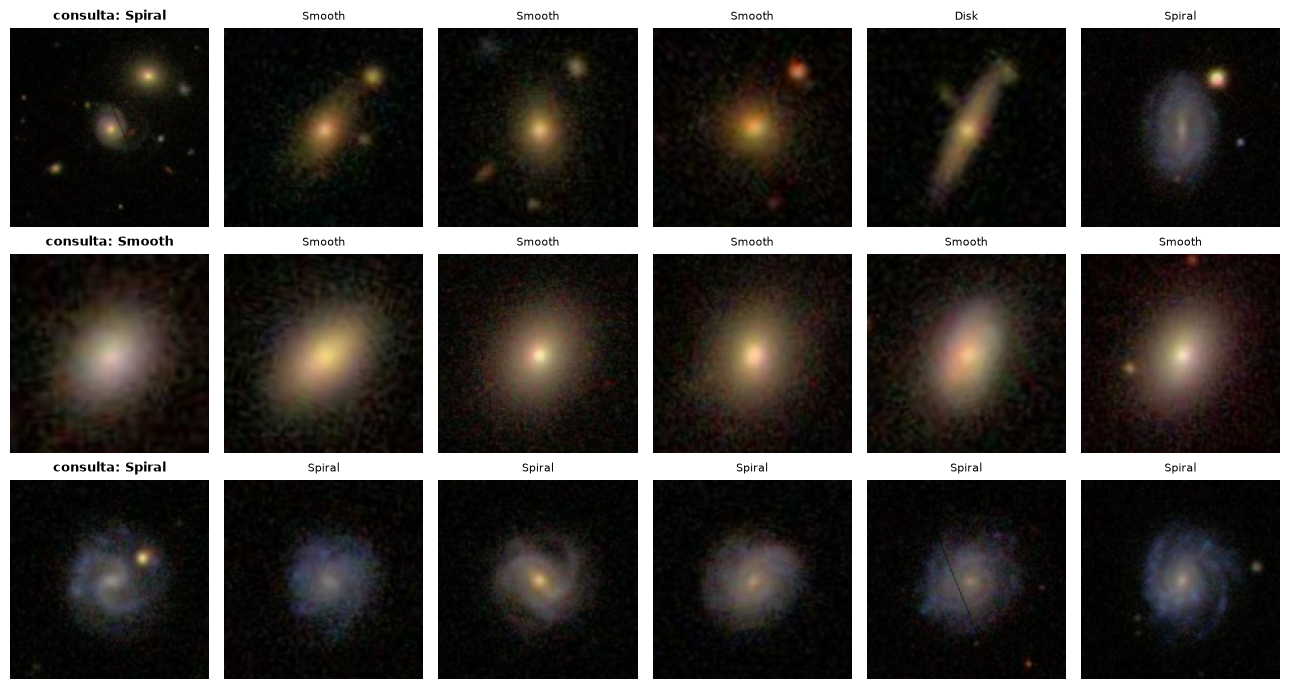

In [11]:
# Galaxias similares — el parche ya dejó `nn` ajustado y `knn.pkl` guardado.
# Solo queda la demostración visual.
_, vec = nn.kneighbors(Zte_[:3])

imgs, ids_cache = data.cargar_cache(128)
pos = {int(g): i for i, g in enumerate(ids_cache)}

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for f in range(3):
    axes[f, 0].imshow(imgs[pos[int(d["test"]["ids"][f])]])
    axes[f, 0].set_title(f'consulta: {clases[yte[f]]}', fontsize=9, fontweight="bold")
    for c in range(5):
        j = vec[f, c]                      # sin +1: la consulta viene de test,
        axes[f, c+1].imshow(imgs[pos[int(d["train"]["ids"][j])]])
        axes[f, c+1].set_title(clases[ytr[j]], fontsize=8)
    for a in axes[f]:
        a.axis("off")
plt.tight_layout()
plt.savefig(evaluate.DIR_FIG / "knn_vecinos.png", dpi=140)
plt.show()

## 3. MLP sobre PCA

Misma entrada que el SVM del día 1, frontera de decisión distinta.

In [12]:
import tensorflow as tf, keras

In [13]:
def entrenar_mlp(nombre, Xtr, Xva, Xte, capas=(256, 128), epocas=120, batch=256):
    keras.backend.clear_session()
    m = models.build_mlp(Xtr.shape[1], len(clases), capas=capas)
    ruta = str(data.RAIZ / "models" / f"{evaluate._slug(nombre)}.keras")
    t0 = time.time()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epocas, batch_size=batch,
              class_weight=models.pesos_clase(ytr),
              callbacks=models.callbacks_estandar(ruta, paciencia=15), verbose=0)
    t_fit = time.time() - t0
    t0 = time.time(); proba = np.asarray(m.predict(Xte, verbose=0), dtype=float)
    t_inf = time.time() - t0
    r = evaluate.evaluar(nombre, yte, proba.argmax(1), proba, clases, t_fit, t_inf)
    np.savez_compressed(evaluate.DIR_REP / f"pred_{evaluate._slug(nombre)}.npz",
                        y_true=yte, y_pred=proba.argmax(1), proba=proba,
                        ids=d["test"]["ids"])
    print(f"{nombre:16s} acc={r['accuracy']:.4f}  F1-macro={r['macro_f1']:.4f}"
          f"  AUC={r['roc_auc_macro']:.4f}  ({t_fit:.0f}s, {len(h.history['loss'])} ép.)")
    return m, h, r

mlp_pca, h_pca, r_pca = entrenar_mlp("MLP-PCA", Ztr, Zva, Zte_)

I0000 00:00:1787795649.908283   77676 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9
I0000 00:00:1787795652.345355   77942 service.cc:152] XLA service 0x7db3800035b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787795652.345371   77942 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
I0000 00:00:1787795652.598410   77942 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1787795654.349210   77942 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 13.
MLP-PCA          acc=0.8790  F1-macro=0.8535  AUC=0.9647  (9s, 28 ép.)


## 4. MLP sobre parámetros morfológicos — experimento tipo Banerji

Aquí no hay píxeles: solo 24 números interpretables (concentración, colores
proxy, asimetría, Gini, Hu, textura). Es la réplica del enfoque de Banerji et
al. 2010 que el resumen promete.

**Al presentar**: los JPEG del Galaxy Zoo Challenge tienen estiramiento asinh no
lineal, así que colores y concentración son *proxies derivados de la imagen*, no
fotometría SDSS calibrada. Decirlo explícitamente.

In [14]:
sc_pa = StandardScaler().fit(Xtr_pa)
Atr, Ava, Ate = sc_pa.transform(Xtr_pa), sc_pa.transform(Xva_pa), sc_pa.transform(Xte_pa)
joblib.dump(sc_pa, data.RAIZ / "models" / "scaler_params.pkl")

mlp_pa, h_pa, r_pa = entrenar_mlp("MLP-Params", Atr, Ava, Ate, capas=(128, 64))


Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 65: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 66: early stopping
Restoring model weights from the end of the best epoch: 51.
MLP-Params       acc=0.8770  F1-macro=0.8515  AUC=0.9634  (12s, 66 ép.)


In [15]:
# Fusión: ¿los parámetros aportan algo que el PCA no captura ya?
Ftr = np.hstack([Ztr, Atr]); Fva = np.hstack([Zva, Ava]); Fte = np.hstack([Zte_, Ate])
mlp_fu, h_fu, r_fu = entrenar_mlp("MLP-Fusion", Ftr, Fva, Fte, capas=(384, 192))


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.
MLP-Fusion       acc=0.8773  F1-macro=0.8509  AUC=0.9606  (7s, 24 ép.)


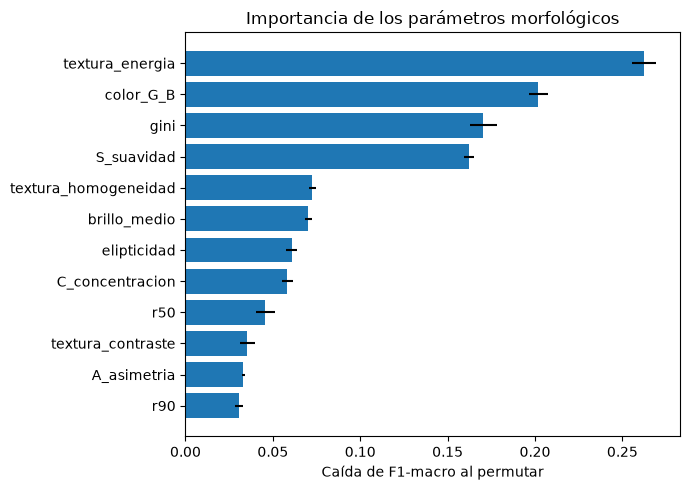

In [16]:
# ¿Qué parámetros pesan? Permutación sobre el modelo de 24 dims.
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

class Wrap(BaseEstimator, ClassifierMixin):
    def __init__(s, m): s.m = m; s.classes_ = np.arange(len(clases))
    def fit(s, X, y): return s
    def predict(s, X): return np.asarray(s.m.predict(X, verbose=0)).argmax(1)

imp = permutation_importance(Wrap(mlp_pa), Ate, yte, n_repeats=6,
                             random_state=42, scoring="f1_macro")
orden = imp.importances_mean.argsort()[::-1][:12]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([features.NOMBRES_PARAMETROS[i] for i in orden][::-1],
        imp.importances_mean[orden][::-1],
        xerr=imp.importances_std[orden][::-1])
ax.set_xlabel("Caída de F1-macro al permutar")
ax.set_title("Importancia de los parámetros morfológicos")
plt.tight_layout(); plt.savefig(evaluate.DIR_FIG / "importancia_params.png", dpi=150)
plt.show()

Si `C_concentracion` y los colores encabezan la lista, el resultado reproduce lo
que reporta la literatura y es una frase directa para la ponencia.

## 5. Comparación parcial

In [17]:
display(evaluate.tabla_comparativa())

,Modelo,Accuracy,F1-macro,AUC-ROC,AP-macro,t entren. (s),t infer. (s)
6,CNN 128px,0.9624,0.9456,0.9926,0.9793,795.7611,2.2457
8,MLP-PCA,0.8790,0.8535,0.9647,0.9267,9.0300,0.4532
9,MLP-Params,0.8770,0.8515,0.9634,0.9246,11.8053,0.4169
10,MLP-Fusion,0.8773,0.8509,0.9606,0.9200,6.7407,0.4286
3,SVM (RBF),0.8616,0.8357,0.9505,0.9036,76.9652,3.1383
1,SVM (RGB + recorte),0.8616,0.8357,0.9505,0.9036,100.5054,2.7280
0,"SVM (gris, sin recorte)",0.8323,0.8112,0.9305,0.8737,34.7204,1.9661
7,KNN,0.8092,0.7909,0.9285,0.8756,39.8553,0.1851
2,Regresión logística,0.7218,0.6823,0.8488,0.7128,73.1482,0.2089
5,SGD (log-loss),0.7175,0.6685,0.7969,0.6189,52.4838,0.1680


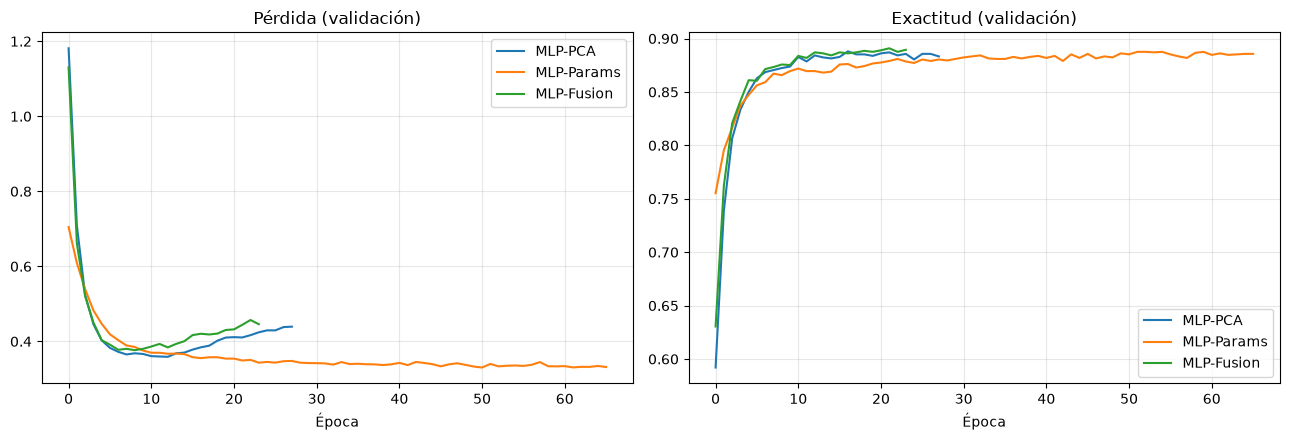

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for nom, h in [("MLP-PCA", h_pca), ("MLP-Params", h_pa), ("MLP-Fusion", h_fu)]:
    ax[0].plot(h.history["val_loss"], label=nom)
    ax[1].plot(h.history["val_accuracy"], label=nom)
ax[0].set_title("Pérdida (validación)"); ax[1].set_title("Exactitud (validación)")
for a in ax: a.set_xlabel("Época"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(evaluate.DIR_FIG / "curvas_mlp.png", dpi=150); plt.show()

## 6. Lanzar la CNN

Desde **otra terminal**, para que el notebook siga libre:

```bash
cd ~/Documentos/GalaxIA && source GalIA/bin/activate
python scripts/train_cnn.py --size 128 --epocas 40 --batch 128
```

Unos 25-40 s por época con `mixed_float16`; 40 épocas son 20-25 minutos.
Escribe en `metrics.json` igual que los demás modelos.

Si sobra tiempo, generen el caché de 224 y lancen una segunda corrida: a esa
resolución los brazos espirales se distinguen bastante mejor.

```bash
python scripts/build_cache.py --size 224
python scripts/train_cnn.py --size 224 --epocas 30 --batch 64
```

## 7. Cierre del día 2

- [ ] KNN, MLP-PCA, MLP-Params y MLP-Fusion en `metrics.json`
- [ ] `models/knn.pkl` con el índice de vecinos para la interfaz
- [ ] `models/pca_px.pkl` y `models/scaler_params.pkl` guardados
- [ ] `pred_*.npz` de cada modelo (los necesita McNemar el día 3)
- [ ] CNN lanzada
- [ ] Figura de importancia de parámetros revisada